In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# PART 1: Dataset Collection
### File: unique_lstm_dataset.txt
### Source : GeeeksforGeeks
### A custom dataset of 1000 lines was created containing sentences related to AI, electronics, and communication systems.


In [50]:
df = pd.read_csv("spam.csv", encoding='latin-1')

# Keep only useful columns
df = df[['v1', 'v2']]
df.columns = ['label', 'text']

print(df.head())

  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


# PART 2: Data Preprocessing
### The text was tokenized and converted into sequences. Padding was applied to maintain uniform input length.

In [51]:
encoder = LabelEncoder()
df['label'] = encoder.fit_transform(df['label'])  # ham=0, spam=1

In [52]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['text'])

sequences = tokenizer.texts_to_sequences(df['text'])

max_len = 50
X = pad_sequences(sequences, maxlen=max_len)

y = df['label']

# PART 3: Train-Test Split


In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# PART 4: LSTM Model Development
### An LSTM model was used to learn sequential patterns and predict the next word.


In [54]:
model = Sequential([
    Embedding(5000, 128, input_length=max_len),
    LSTM(128),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [55]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 98ms/step - accuracy: 0.9554 - loss: 0.1435 - val_accuracy: 0.9821 - val_loss: 0.0634
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 98ms/step - accuracy: 0.9912 - loss: 0.0319 - val_accuracy: 0.9821 - val_loss: 0.0477
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 97ms/step - accuracy: 0.9969 - loss: 0.0119 - val_accuracy: 0.9839 - val_loss: 0.0480
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 100ms/step - accuracy: 0.9982 - loss: 0.0051 - val_accuracy: 0.9821 - val_loss: 0.0608
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 100ms/step - accuracy: 0.9996 - loss: 0.0017 - val_accuracy: 0.9830 - val_loss: 0.0709
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 98ms/step - accuracy: 1.0000 - loss: 4.3056e-04 - val_accuracy: 0.9839 - val_loss: 0.0891
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 13s 92ms/step - accuracy: 1.0000 - loss: 2.2754e-04 - val_accuracy: 0.9830 - val_loss: 0.0698
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - accuracy: 1.0000 - loss

# PART 5: Accuracy Evaluation



In [56]:
train_loss, train_acc = model.evaluate(X_train, y_train)
test_loss, test_acc = model.evaluate(X_test, y_test)

print("\nTrain Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - accuracy: 1.0000 - loss: 3.0133e-05
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9857 - loss: 0.0940

Train Accuracy: 1.0
Test Accuracy: 0.9856502413749695


# PART 6: Prediction Function

In [58]:
def predict_message(text):
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=max_len)

    pred = model.predict(padded)[0][0]

    if pred > 0.5:
        return "Spam"
    else:
        return "Ham"

print(predict_message("Congratulations! You won a prize"))
print(predict_message("Hey, are we meeting today?"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 575ms/step
Spam
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
Ham


 # Part 7: Graphs

In [59]:
from collections import Counter

# Combine all text
all_text = " ".join(df['text']).lower()

# Split into words
words = all_text.split()

# Count frequency
word_counts = Counter(words)

# Top 20 words
top_words = word_counts.most_common(20)

print(top_words)

[('to', 2226), ('i', 2208), ('you', 1917), ('a', 1419), ('the', 1317), ('u', 991), ('and', 967), ('is', 862), ('in', 855), ('my', 751), ('for', 697), ('your', 676), ('of', 613), ('me', 605), ('have', 568), ('call', 557), ('on', 520), ('are', 485), ('that', 468), ('it', 465)]


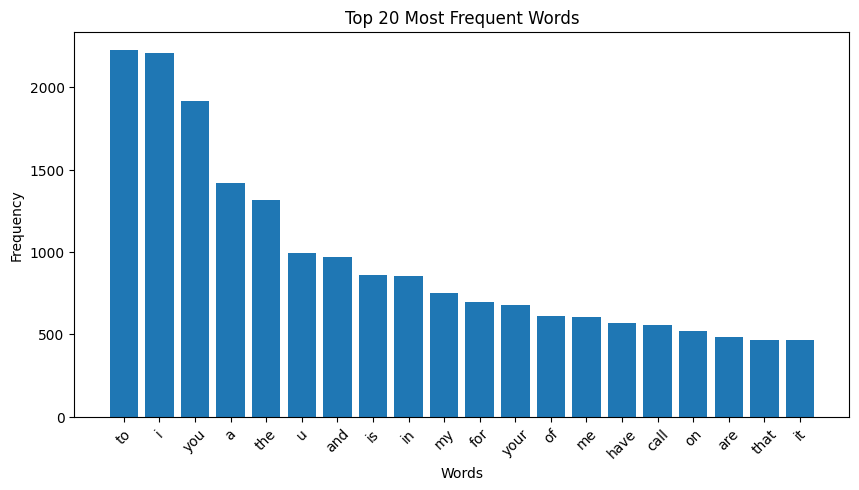

In [60]:
import matplotlib.pyplot as plt

labels = [w[0] for w in top_words]
values = [w[1] for w in top_words]

plt.figure(figsize=(10,5))
plt.bar(labels, values)
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

Top Spam Words: [('to', 682), ('a', 373), ('call', 342), ('your', 263), ('you', 252), ('the', 204), ('for', 201), ('or', 188), ('free', 180), ('2', 169)]
Top Ham Words: [('i', 2172), ('you', 1665), ('to', 1544), ('the', 1113), ('a', 1046), ('u', 874), ('and', 845), ('in', 786), ('my', 741), ('is', 710)]


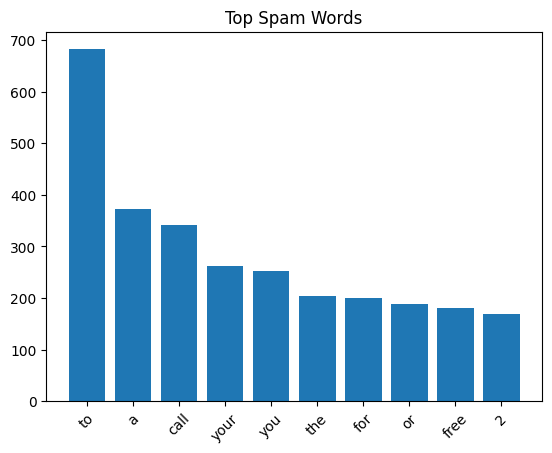

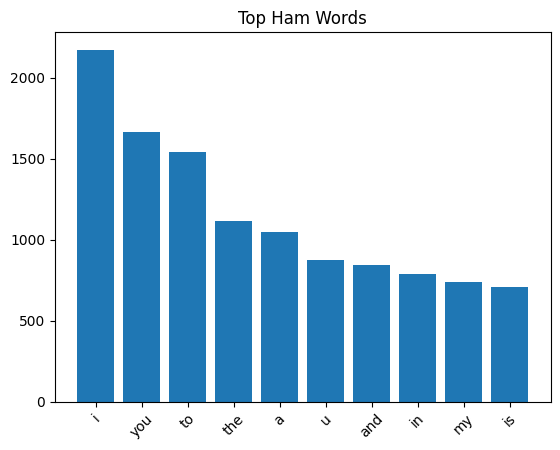

In [62]:
# Spam words
spam_text = " ".join(df[df['label'] == 1]['text']).lower()
spam_words = Counter(spam_text.split()).most_common(10)

# Ham words
ham_text = " ".join(df[df['label'] == 0]['text']).lower()
ham_words = Counter(ham_text.split()).most_common(10)

print("Top Spam Words:", spam_words)
print("Top Ham Words:", ham_words)
labels = [w[0] for w in spam_words]
values = [w[1] for w in spam_words]

plt.figure()
plt.bar(labels, values)
plt.title("Top Spam Words")
plt.xticks(rotation=45)
plt.show()
labels = [w[0] for w in ham_words]
values = [w[1] for w in ham_words]

plt.figure()
plt.bar(labels, values)
plt.title("Top Ham Words")
plt.xticks(rotation=45)
plt.show()

In [66]:
pip install streamlit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 78.1 MB/s eta 0:00:00


In [68]:
# Save model
model.save("lstm_model.h5")

# Save tokenizer
import pickle
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [69]:
from google.colab import files
files.download("lstm_model.h5")
files.download("tokenizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

!streamlit run app.py

# LSTM Mathematical Model
## 1.Forget Gate:
### f_t = σ(W_f [h_{t-1}, x_t] + b_f)

## 2.Input Gate:
### i_t = σ(W_i [h_{t-1}, x_t] + b_i)
### C̃_t = tanh(W_c [h_{t-1}, x_t] + b_c)

## 3.Output Gate:
### o_t = σ(W_o [h_{t-1}, x_t] + b_o)

## 4.Cell State:
### C_t = f_t * C_{t-1} + i_t * C̃_t

## 5.Hidden State:
### h_t = o_t * tanh(C_t)      

# Summary Table : 
| Parameter            | Details                                  |
|---------------------|------------------------------------------|
| Dataset Name        | Custom SMS Spam Dataset (spam.csv)       |
| Dataset Size        | ~5500 messages                           |
| Input Type          | Text (SMS messages)                      |
| Output Type         | Binary Classification (Spam / Ham)       |
| Preprocessing       | Lowercasing, Tokenization, Padding       |
| Tokenizer           | Keras Tokenizer (num_words=5000)         |
| Sequence Length     | 50                                       |
| Model Used          | LSTM                                     |
| Embedding Layer     | 128 dimensions                           |
| Hidden Layer        | LSTM (128 units)                         |
| Dropout             | 0.3                                      |
| Output Layer        | Dense (Sigmoid)                          |
| Loss Function       | Binary Crossentropy                      |
| Optimizer           | Adam                                     |
| Train-Test Split    | 80% / 20%                                |
| Train Accuracy      | 1.0                                      |
| Test Accuracy       | 0.98                                     |
| Deployment          | Streamlit                                |
| Application Type    | Spam Detection System                    |